In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../data/data_stemmed.csv", index_col=0)
metadata = pd.read_csv("../data/995,000_rows.csv", usecols=["type", "domain"])

data["type"] = metadata["type"]

In [35]:
data["domain"] = metadata["domain"]

In [23]:
data["email_count"] = data["content"].str.count("<email>")
data["url_count"] = data["content"].str.count("<url>")
data["date_count"] = data["content"].str.count("<date>")
data["num_count"] = data["content"].str.count("<num>")

In [27]:
data[data["type"] == "bias"]["num_count"].mean()

np.float64(6.505404107121413)

In [31]:
data.groupby("type")[["email_count", "url_count", "date_count", "num_count"]].mean()

,email_count,url_count,date_count,num_count
type,,,,
2018-02-10 13:43:39.521661,0.000000,0.000000,0.000000,1.000000
bias,0.005839,0.434655,0.706174,6.505404
clickbait,0.000328,0.903509,1.966219,7.244783
conspiracy,0.020758,1.388516,0.701050,6.744384
fake,0.051162,1.114242,0.677717,8.932000
hate,0.003303,0.384212,3.971637,17.662148
junksci,0.008191,3.175142,0.391809,7.535328
political,0.018425,0.352379,0.916429,8.941671
reliable,0.014623,0.388259,0.940141,11.610950


In [32]:
data.groupby("type")[["email_count", "url_count", "date_count", "num_count"]].max()

,email_count,url_count,date_count,num_count
type,,,,
2018-02-10 13:43:39.521661,0,0,0,1
bias,21,367,414,2074
clickbait,1,56,151,402
conspiracy,45,2015,215,4190
fake,134,565,290,2243
hate,8,145,379,1089
junksci,14,82,58,1030
political,70,481,1031,3661
reliable,19,184,411,1640


In [33]:
data.groupby("type")[["email_count", "url_count", "date_count", "num_count"]].min()

,email_count,url_count,date_count,num_count
type,,,,
2018-02-10 13:43:39.521661,0,0,0,1
bias,0,0,0,0
clickbait,0,0,0,0
conspiracy,0,0,0,0
fake,0,0,0,0
hate,0,0,0,0
junksci,0,0,0,0
political,0,0,0,0
reliable,0,0,0,0


### Exploring domains

In [38]:
domain_counts = data["domain"].value_counts()

<Axes: xlabel='domain'>

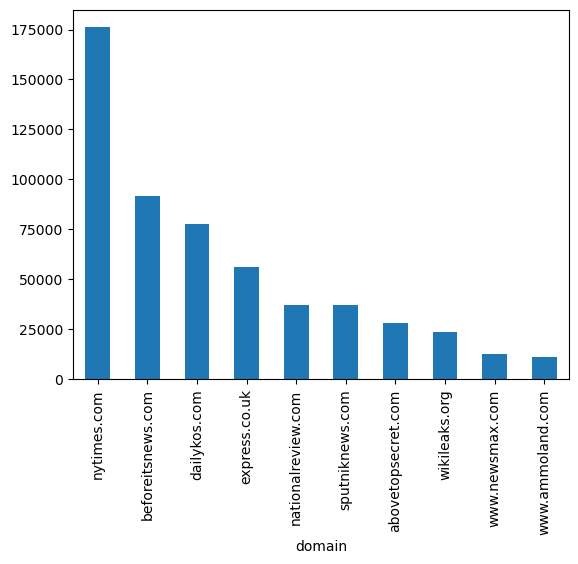

In [41]:
domain_counts.iloc[:10].plot(kind="bar")